In [1]:
import requests
import pandas as pd
import time

In [2]:
def extract_race_result(race_dict, result_dict):
    return {
        'season':      int(race_dict['season']),
        'round':       int(race_dict['round']),
        'race_name':   race_dict['raceName'],
        'driver':      result_dict['Driver']['driverId'],
        'constructor': result_dict['Constructor']['constructorId'],
        'grid':        int(result_dict['grid']),
        'position':    int(result_dict['position']),
        'points':      float(result_dict['points']),
        'status':      result_dict['status'],
        'laps':        int(result_dict['laps']),
    }

def parse_season_response(data):
    races = data['MRData']['RaceTable']['Races']
    all_rows = []
    for race in races:
        for result in race['Results']:
            all_rows.append(extract_race_result(race, result))
    return all_rows

def fetch_season_results(season):
    all_rows = []
    offset = 0
    limit = 100
    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{season}/results.json?limit={limit}&offset={offset}"
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Warning: failed for season {season} — status {response.status_code}")
            break
        data = response.json()
        total = int(data['MRData']['total'])
        rows = parse_season_response(data)
        all_rows.extend(rows)
        offset += limit
        if offset >= total:
            break
        time.sleep(0.3)
    return all_rows

In [3]:
all_seasons = []

for season in range(2010, 2025):
    print(f"Fetching {season}...")
    all_seasons.extend(fetch_season_results(season))
    time.sleep(0.5)

print(f"\nTotal rows: {len(all_seasons)}")

Fetching 2010...
Fetching 2011...
Fetching 2012...
Fetching 2013...
Fetching 2014...
Fetching 2015...
Fetching 2016...
Fetching 2017...
Fetching 2018...
Fetching 2019...
Fetching 2020...
Fetching 2021...
Fetching 2022...
Fetching 2023...
Fetching 2024...

Total rows: 6432


In [4]:
df_results = pd.DataFrame(all_seasons)
print(df_results.shape)
print(df_results.head())
df_results.to_csv('f1_race_results_2010_2024.csv', index=False)
print("Saved.")

(6432, 10)
   season  round           race_name    driver constructor  grid  position  \
0    2010      1  Bahrain Grand Prix    alonso     ferrari     3         1   
1    2010      1  Bahrain Grand Prix     massa     ferrari     2         2   
2    2010      1  Bahrain Grand Prix  hamilton     mclaren     4         3   
3    2010      1  Bahrain Grand Prix    vettel    red_bull     1         4   
4    2010      1  Bahrain Grand Prix   rosberg    mercedes     5         5   

   points    status  laps  
0    25.0  Finished    49  
1    18.0  Finished    49  
2    15.0  Finished    49  
3    12.0  Finished    49  
4    10.0  Finished    49  
Saved.


In [5]:
df = pd.read_csv('f1_race_results_2010_2024.csv')
print(df.shape)
print(df.dtypes)
print(df['position'].unique())

(6432, 10)
season           int64
round            int64
race_name          str
driver             str
constructor        str
grid             int64
position         int64
points         float64
status             str
laps             int64
dtype: object
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


In [7]:
# Create binary target: 1 = podium (positions 1-3), 0 = no podium
df['podium'] = (df['position'] <= 3).astype(int)

# Check status values to understand retirements
print(df['status'].value_counts().head(20))

# Check class balance
print(f"\nPodium finishes: {df['podium'].sum()}")
print(f"Non-podium: {(df['podium'] == 0).sum()}")
print(f"Podium rate: {df['podium'].mean():.2%}")


status
Finished            3305
+1 Lap              1342
+2 Laps              314
Collision            215
Lapped               208
Retired              157
Accident             122
Engine                90
+3 Laps               67
Gearbox               63
Brakes                53
Collision damage      47
Hydraulics            43
Suspension            43
Power Unit            41
+4 Laps               22
Wheel                 21
Electrical            18
Spun off              15
Oil leak              14
Name: count, dtype: int64

Podium finishes: 915
Non-podium: 5517
Podium rate: 14.23%


In [10]:
all_qualifying = []

for season in range(2010, 2025):
    print(f"Fetching qualifying {season}...")
    all_qualifying.extend(fetch_season_qualifying(season))
    time.sleep(0.5)

df_qualifying = pd.DataFrame(all_qualifying)
print(f"\nQualifying rows: {len(df_qualifying)}")
print(df_qualifying.head())

def extract_qualifying_result(race_dict, qual_dict):
    return {
        'season':   int(race_dict['season']),
        'round':    int(race_dict['round']),
        'driver':   qual_dict['Driver']['driverId'],
        'grid':     int(qual_dict['position']),
    }

def parse_qualifying_response(data):
    races = data['MRData']['RaceTable']['Races']
    all_rows = []
    for race in races:
        for result in race['QualifyingResults']:
            all_rows.append(extract_qualifying_result(race, result))
    return all_rows

def fetch_season_qualifying(season):
    all_rows = []
    offset = 0
    limit = 100

    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{season}/qualifying.json?limit={limit}&offset={offset}"
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Warning: failed for season {season}")
            break

        data = response.json()
        total = int(data['MRData']['total'])
        rows = parse_qualifying_response(data)
        all_rows.extend(rows)

        offset += limit
        if offset >= total:
            break

        time.sleep(0.3)

    return all_rows

Fetching qualifying 2010...
Fetching qualifying 2011...
Fetching qualifying 2012...
Fetching qualifying 2013...
Fetching qualifying 2014...
Fetching qualifying 2015...
Fetching qualifying 2016...
Fetching qualifying 2017...
Fetching qualifying 2018...
Fetching qualifying 2019...
Fetching qualifying 2020...
Fetching qualifying 2021...
Fetching qualifying 2022...
Fetching qualifying 2023...
Fetching qualifying 2024...

Qualifying rows: 6412
   season  round    driver  grid
0    2010      1    vettel     1
1    2010      1     massa     2
2    2010      1    alonso     3
3    2010      1  hamilton     4
4    2010      1   rosberg     5


In [12]:
# Rename qualifying grid to avoid confusion with race grid
df_qualifying = df_qualifying.rename(columns={'grid': 'qualifying_position'})

# Merge on season, round, driver
df_merged = df.merge(df_qualifying, on=['season', 'round', 'driver'], how='inner')

print(f"Merged rows: {len(df_merged)}")
print(df_merged[['season', 'round', 'driver', 'qualifying_position', 'position', 'podium']].head(10))

Merged rows: 9006
   season  round    driver  qualifying_position  position  podium
0    2010      1    alonso                    3         1       1
1    2010      1    alonso                    3         1       1
2    2010      1     massa                    2         2       1
3    2010      1     massa                    2         2       1
4    2010      1  hamilton                    4         3       1
5    2010      1  hamilton                    4         3       1
6    2010      1    vettel                    1         4       0
7    2010      1    vettel                    1         4       0
8    2010      1   rosberg                    5         5       0
9    2010      1   rosberg                    5         5       0


In [16]:
# Drop qualifying duplicates
df_qualifying = df_qualifying.drop_duplicates(subset=['season', 'round', 'driver'])
print(f"Qualifying rows after dedup: {len(df_qualifying)}")

# Rename and merge
df_qualifying = df_qualifying.rename(columns={'grid': 'qualifying_position'})
df_merged = df.merge(df_qualifying, on=['season', 'round', 'driver'], how='inner')

print(f"Merged rows: {len(df_merged)}")
print(df_merged[['season', 'round', 'driver', 'qualifying_position', 'position', 'podium']].head(10))

Qualifying rows after dedup: 6412
Merged rows: 6408
   season  round              driver  qualifying_position  position  podium
0    2010      1              alonso                    3         1       1
1    2010      1               massa                    2         2       1
2    2010      1            hamilton                    4         3       1
3    2010      1              vettel                    1         4       0
4    2010      1             rosberg                    5         5       0
5    2010      1  michael_schumacher                    7         6       0
6    2010      1              button                    8         7       0
7    2010      1              webber                    6         8       0
8    2010      1              liuzzi                   12         9       0
9    2010      1         barrichello                   11        10       0


In [18]:
# Step 1: total constructor points earned each round
round_points = df_merged.groupby(['season', 'round', 'constructor'])['points'].sum().reset_index()
round_points.columns = ['season', 'round', 'constructor', 'round_total']

# Step 2: cumulative sum minus current round = points BEFORE this race
round_points = round_points.sort_values(['season', 'constructor', 'round'])
round_points['constructor_points'] = (
    round_points.groupby(['season', 'constructor'])['round_total'].cumsum()
    - round_points['round_total']
)

# Step 3: merge back
df_merged = df_merged.drop(columns=['constructor_points'], errors='ignore')
df_merged = df_merged.merge(
    round_points[['season', 'round', 'constructor', 'constructor_points']],
    on=['season', 'round', 'constructor'],
    how='left'
)

print(df_merged[['season', 'round', 'constructor', 'constructor_points', 'podium']].head(20))

    season  round   constructor  constructor_points  podium
0     2010      1       ferrari                 0.0       1
1     2010      1       ferrari                 0.0       1
2     2010      1   force_india                 0.0       0
3     2010      1   force_india                 0.0       0
4     2010      1           hrt                 0.0       0
5     2010      1           hrt                 0.0       0
6     2010      1  lotus_racing                 0.0       0
7     2010      1  lotus_racing                 0.0       0
8     2010      1       mclaren                 0.0       1
9     2010      1       mclaren                 0.0       0
10    2010      1      mercedes                 0.0       0
11    2010      1      mercedes                 0.0       0
12    2010      1      red_bull                 0.0       0
13    2010      1      red_bull                 0.0       0
14    2010      1       renault                 0.0       0
15    2010      1       renault         

In [19]:
print(df_merged[df_merged['round'] == 2][['season', 'round', 'constructor', 'constructor_points', 'podium']].head(20))

    season  round   constructor  constructor_points  podium
24    2010      2       ferrari                43.0       1
25    2010      2       ferrari                43.0       0
26    2010      2   force_india                 2.0       0
27    2010      2   force_india                 2.0       0
28    2010      2           hrt                 0.0       0
29    2010      2           hrt                 0.0       0
30    2010      2  lotus_racing                 0.0       0
31    2010      2  lotus_racing                 0.0       0
32    2010      2       mclaren                21.0       1
33    2010      2       mclaren                21.0       0
34    2010      2      mercedes                18.0       0
35    2010      2      mercedes                18.0       0
36    2010      2      red_bull                16.0       0
37    2010      2      red_bull                16.0       0
38    2010      2       renault                 0.0       1
39    2010      2       renault         

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Select features and target
features = ['qualifying_position', 'constructor_points']
target = 'podium'

# Drop any rows with missing values
df_model = df_merged[features + [target, 'season']].dropna()

# Split by season to avoid data leakage
train = df_model[df_model['season'] <= 2020]
test = df_model[df_model['season'] >= 2021]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Train podium rate: {y_train.mean():.2%}")
print(f"Test podium rate: {y_test.mean():.2%}")

Training rows: 4610 | Test rows: 1798
Train podium rate: 13.99%
Test podium rate: 15.02%


In [21]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

  # Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Results
for name, preds in [('Logistic Regression', lr_preds), ('Random Forest', rf_preds)]:
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, preds):.3f}")
    print(f"Precision: {precision_score(y_test, preds):.3f}")
    print(f"Recall:    {recall_score(y_test, preds):.3f}")
    print(f"F1 Score:  {f1_score(y_test, preds):.3f}")


--- Logistic Regression ---
Accuracy:  0.815
Precision: 0.445
Recall:    0.926
F1 Score:  0.601

--- Random Forest ---
Accuracy:  0.854
Precision: 0.513
Recall:    0.578
F1 Score:  0.544


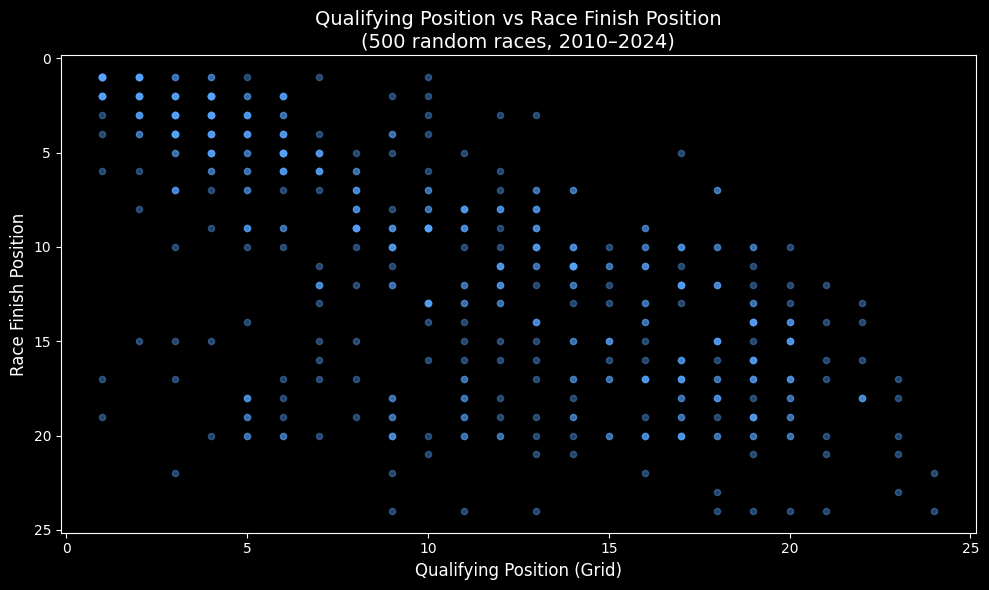

Saved.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

sample = df_merged.sample(500, random_state=42)
scatter = ax.scatter(sample['qualifying_position'], sample['position'],
                    alpha=0.4, s=20, c='#58a6ff')

ax.set_xlabel('Qualifying Position (Grid)', fontsize=12)
ax.set_ylabel('Race Finish Position', fontsize=12)
ax.set_title('Qualifying Position vs Race Finish Position\n(500 random races, 2010–2024)', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('qualifying_vs_finish.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

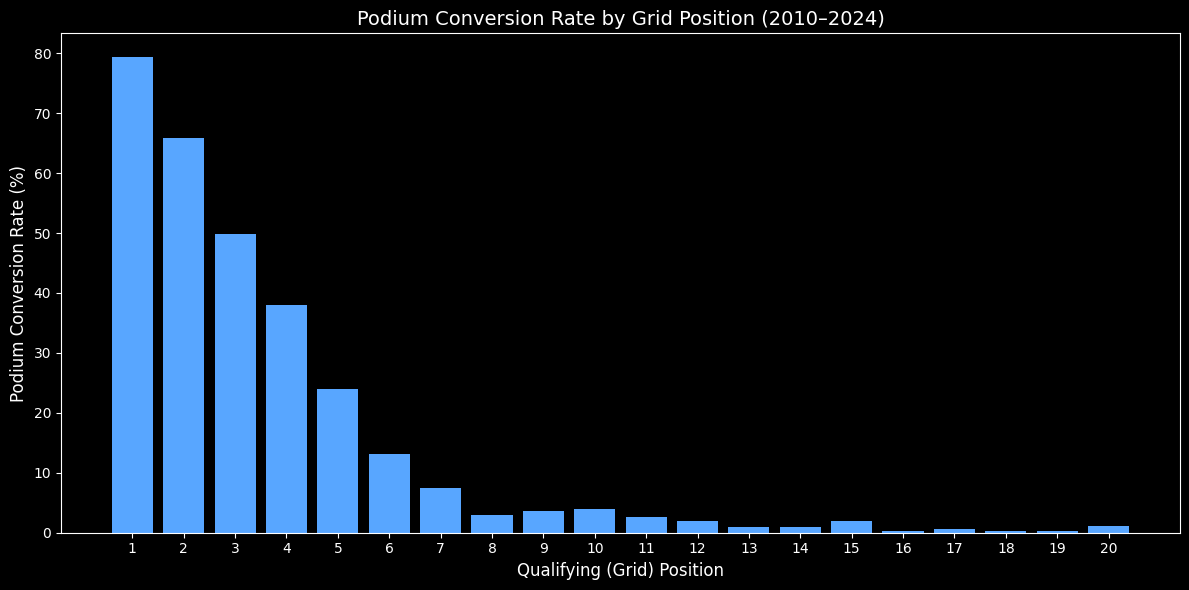

Saved.


In [23]:
podium_rate = df_merged.groupby('qualifying_position')['podium'].mean() * 100
podium_rate = podium_rate[podium_rate.index <= 20]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(podium_rate.index, podium_rate.values, color='#58a6ff', edgecolor='none')
ax.set_xlabel('Qualifying (Grid) Position', fontsize=12)
ax.set_ylabel('Podium Conversion Rate (%)', fontsize=12)
ax.set_title('Podium Conversion Rate by Grid Position (2010–2024)', fontsize=14)
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.savefig('podium_conversion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

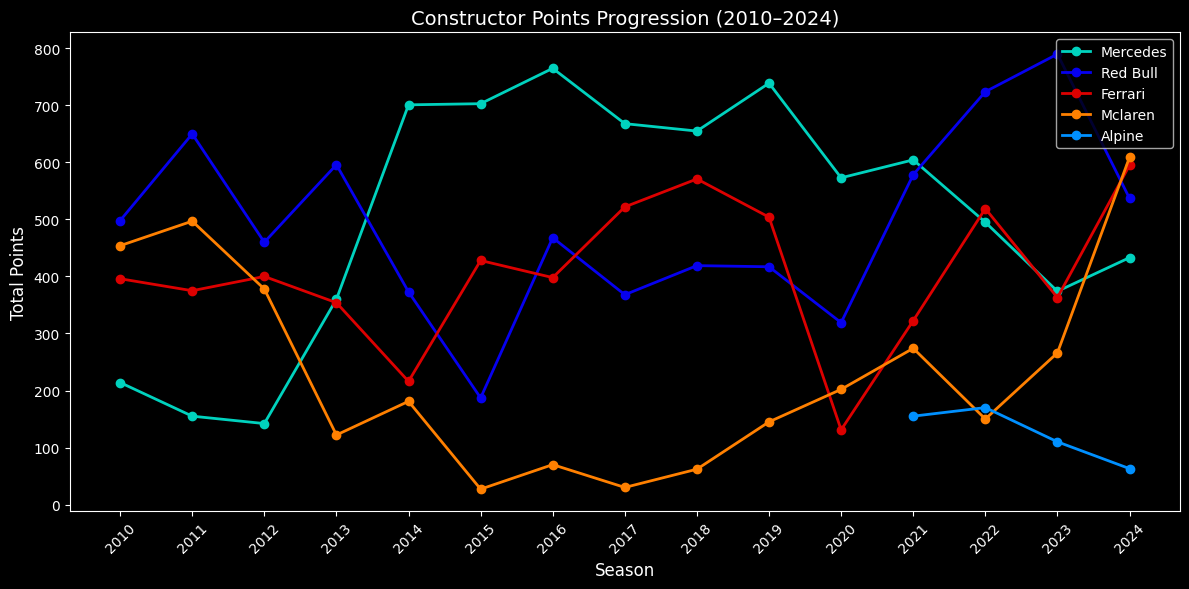

Saved.


In [26]:
top_constructors = ['mercedes', 'red_bull', 'ferrari', 'mclaren', 'alpine']
colors = ['#00d2be', '#0600ef', '#dc0000', '#ff8000', '#0090ff']

constructor_season = df_merged.groupby(['season', 'constructor'])['points'].sum().reset_index()
constructor_season = constructor_season[constructor_season['constructor'].isin(top_constructors)]

fig, ax = plt.subplots(figsize=(12, 6))
for constructor, color in zip(top_constructors, colors):
    data = constructor_season[constructor_season['constructor'] == constructor]
    ax.plot(data['season'], data['points'], marker='o', label=constructor.replace('_', ' ').title(),
            color=color, linewidth=2)

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Total Points', fontsize=12)
ax.set_title('Constructor Points Progression (2010–2024)', fontsize=14)
ax.legend()
ax.set_xticks(range(2010, 2025))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('constructor_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

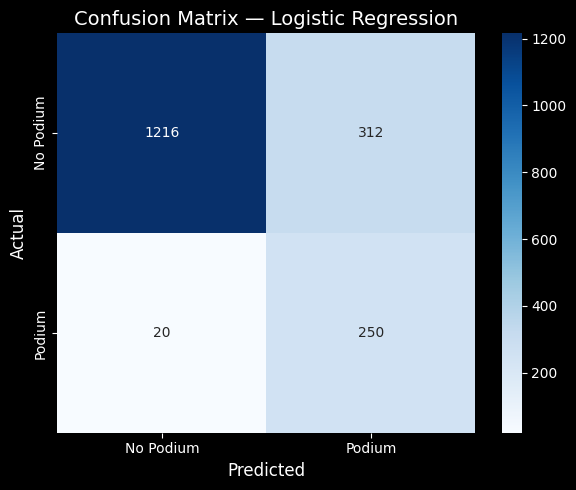

Saved.


In [27]:
cm = confusion_matrix(y_test, lr_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Podium', 'Podium'],
            yticklabels=['No Podium', 'Podium'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

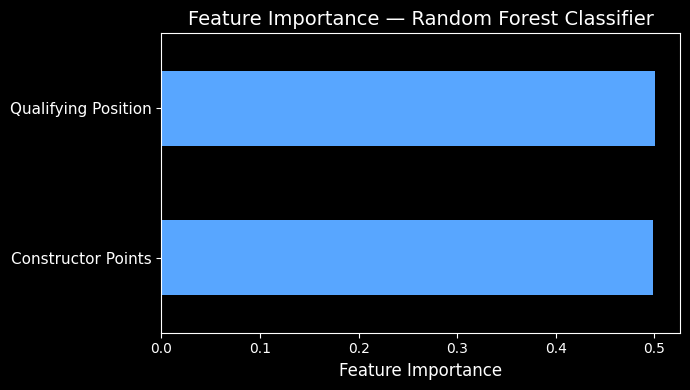

Saved.


In [28]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='#58a6ff')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=14)
ax.set_yticklabels(['Constructor Points', 'Qualifying Position'], fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")
